# **Análisis Exploratorio de Datos (EDA) - Categóricas y Target**

En esta sección se realiza el análisis unidimensional de las variables categóricas del dataset y de la variable objetivo `default`.

El propósito es examinar la distribución de las categorías, identificar posibles problemas de calidad de datos, detectar categorías poco frecuentes y analizar el desbalance de clases en la variable objetivo.

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

DATA_PATH = Path(r"C:\Users\Daniel Rangel\Documents\MachineLearning\Data\accepted_2007_to_2018Q4.csv.gz")

df = pd.read_csv(DATA_PATH, low_memory=False)
df["default"] = df["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)


## **Identificación de variables categóricas**

En primer lugar, se identifican las variables categóricas presentes en el dataset para posteriormente evaluar su nivel de completitud y seleccionar aquellas más relevantes para el análisis.

In [2]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Número de variables categóricas:", len(categorical_cols))

Número de variables categóricas: 38


## **Valores faltantes en variables categóricas**

Se calcula la cantidad y el porcentaje de valores faltantes por variable categórica, con el fin de identificar aquellas que presentan un nivel de completitud adecuado para su análisis.

In [3]:
missing_cat = df[categorical_cols].isnull().sum()
missing_pct_cat = (missing_cat / len(df)) * 100

missing_cat_df = pd.DataFrame({
    "missing": missing_cat,
    "percentage": missing_pct_cat
}).sort_values(by="percentage", ascending=False)

missing_cat_df.head(20)

,missing,percentage
hardship_end_date,2249784,99.517097
payment_plan_start_date,2249784,99.517097
hardship_type,2249784,99.517097
hardship_reason,2249784,99.517097
hardship_status,2249784,99.517097
hardship_start_date,2249784,99.517097
hardship_loan_status,2249784,99.517097
settlement_date,2226455,98.485160
debt_settlement_flag_date,2226455,98.485160
settlement_status,2226455,98.485160


Con base en el análisis de valores faltantes, se utilizará un umbral preliminar del 30% para identificar variables categóricas con un nivel de completitud adecuado.

Este criterio no implica una eliminación automática, sino que funciona como filtro inicial para seleccionar variables candidatas al análisis detallado.

In [4]:
threshold = 30

cat_cols_under_threshold = missing_cat_df[
    missing_cat_df["percentage"] <= threshold
].index.tolist()

print("Número de variables categóricas con <= 30% de missing:", len(cat_cols_under_threshold))
cat_cols_under_threshold

Número de variables categóricas con <= 30% de missing: 24


['emp_title',
 'emp_length',
 'title',
 'last_pymnt_d',
 'last_credit_pull_d',
 'earliest_cr_line',
 'zip_code',
 'initial_list_status',
 'issue_d',
 'grade',
 'sub_grade',
 'debt_settlement_flag',
 'disbursement_method',
 'home_ownership',
 'verification_status',
 'pymnt_plan',
 'loan_status',
 'term',
 'url',
 'purpose',
 'hardship_flag',
 'addr_state',
 'application_type',
 'id']

## **Selección de variables categóricas para el análisis**

A partir del conjunto de variables categóricas que cumplen con el criterio de tener un porcentaje de valores faltantes menor o igual al 30%, se selecciona un subconjunto de variables relevantes para el análisis exploratorio detallado.

La selección se realiza considerando dos criterios principales:

- su relevancia para el problema de predicción de default,
- y su alineación con las variables que serán utilizadas posteriormente en el modelado.

En particular, se trabajará con las variables `emp_length`, `purpose`, `home_ownership` y `addr_state`, ya que representan características importantes del perfil del solicitante y del préstamo.

In [5]:
cat_vars = ["emp_length", "purpose", "home_ownership", "addr_state"]

print("Variables categóricas seleccionadas:")
print(cat_vars)

Variables categóricas seleccionadas:
['emp_length', 'purpose', 'home_ownership', 'addr_state']


In [6]:
missing_selected_cat = df[cat_vars].isnull().sum()
missing_pct_selected_cat = (missing_selected_cat / len(df)) * 100

missing_selected_cat_df = pd.DataFrame({
    "missing": missing_selected_cat,
    "percentage": missing_pct_selected_cat
}).sort_values(by="percentage", ascending=False)

missing_selected_cat_df

,missing,percentage
emp_length,146940,6.499754
purpose,33,0.001460
home_ownership,33,0.001460
addr_state,33,0.001460


Las variables categóricas seleccionadas presentan porcentajes de valores faltantes iguales o inferiores al 30%, por lo que se consideran adecuadas para el análisis exploratorio.

En etapas posteriores de preprocesamiento, los valores faltantes podrán tratarse mediante imputación por moda, creación de una categoría específica como “Desconocido” o, en casos particulares, mediante eliminación si el contexto lo justifica.

A continuación se presentan los valores y sus frecuencias en número y porcentaje para cada variable.

In [7]:
for col in cat_vars:
    freq = df[col].value_counts(dropna=False)
    rel = (df[col].value_counts(dropna=False, normalize=True) * 100).round(2)

    freq_df = pd.DataFrame({
        "frecuencia": freq,
        "porcentaje": rel
    })

    print(f"\nVariable: {col}")
    display(freq_df)


Variable: emp_length


,frecuencia,porcentaje
10+ years,748005,33.09
2 years,203677,9.01
< 1 year,189988,8.40
3 years,180753,8.00
1 year,148403,6.56
NaN,146940,6.50
5 years,139698,6.18
4 years,136605,6.04
6 years,102628,4.54
7 years,92695,4.10



Variable: purpose


,frecuencia,porcentaje
debt_consolidation,1277877,56.53
credit_card,516971,22.87
home_improvement,150457,6.66
other,139440,6.17
major_purchase,50445,2.23
medical,27488,1.22
small_business,24689,1.09
car,24013,1.06
vacation,15525,0.69
moving,15403,0.68



Variable: home_ownership


,frecuencia,porcentaje
MORTGAGE,1111450,49.16
RENT,894929,39.59
OWN,253057,11.19
ANY,996,0.04
OTHER,182,0.01
NONE,54,0.00
NaN,33,0.00



Variable: addr_state


,frecuencia,porcentaje
CA,314533,13.91
NY,186389,8.24
TX,186335,8.24
FL,161991,7.17
IL,91173,4.03
NJ,83132,3.68
PA,76939,3.40
OH,75132,3.32
GA,74196,3.28
VA,62954,2.78


## **Categorías con baja frecuencia**

Se identifican las categorías con una frecuencia relativa inferior al 1%, ya que estas podrían agruparse posteriormente en una categoría como “Otros” en la etapa de preprocesamiento.

In [8]:
rare_categories = {}

for col in cat_vars:
    pct = df[col].value_counts(normalize=True, dropna=False) * 100
    rare_categories[col] = pct[pct < 1].sort_values()

for col, rare in rare_categories.items():
    print(f"\nVariable: {col}")
    if len(rare) == 0:
        print("No hay categorías con frecuencia menor al 1%")
    else:
        print(rare)


Variable: emp_length
No hay categorías con frecuencia menor al 1%

Variable: purpose
NaN                 0.001460
educational         0.018755
renewable_energy    0.063918
wedding             0.104171
house               0.625293
moving              0.681337
vacation            0.686734
Name: purpose, dtype: float64

Variable: home_ownership
NaN      0.001460
NONE     0.002389
OTHER    0.008051
ANY      0.044057
Name: home_ownership, dtype: float64

Variable: addr_state
IA     0.000619
NaN    0.001460
ND     0.158845
ID     0.190560
SD     0.201221
WY     0.210023
VT     0.218384
ME     0.220020
AK     0.231388
DC     0.236918
MT     0.278630
DE     0.285664
NE     0.345866
WV     0.369399
RI     0.442562
HI     0.471889
NH     0.492856
NM     0.530190
MS     0.559074
UT     0.663201
AR     0.755252
KS     0.845269
OK     0.915247
KY     0.968151
Name: addr_state, dtype: float64


## **Visualización de variables categóricas**

Se generan gráficos de barras para visualizar la distribución de las variables categóricas seleccionadas.

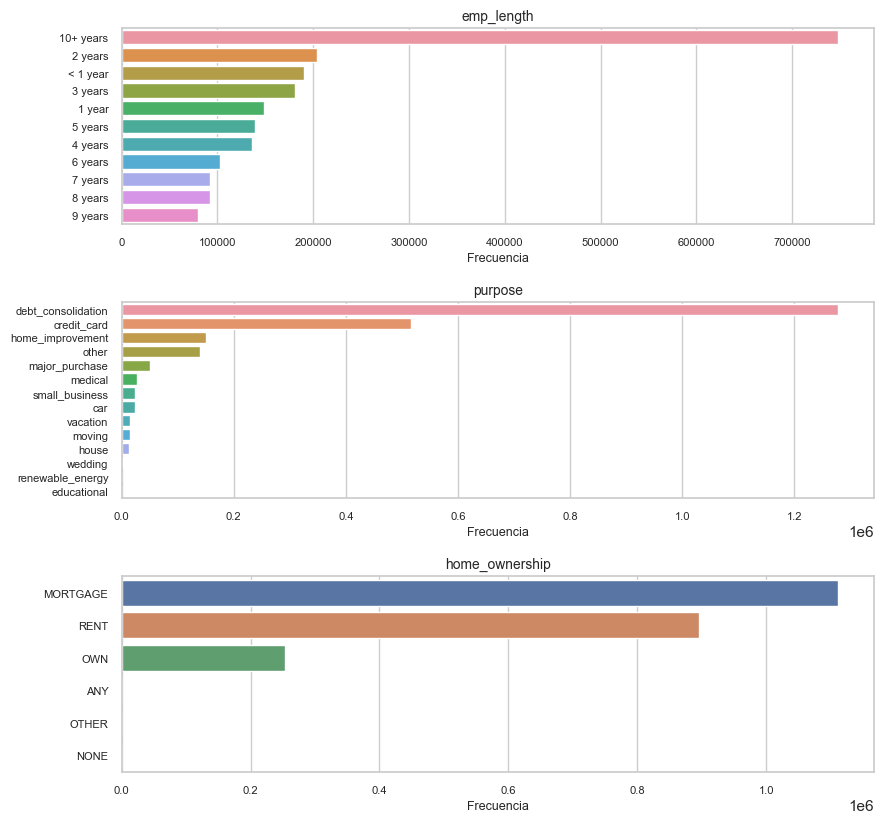

In [9]:
main_cat_vars = ["emp_length", "purpose", "home_ownership"]

fig, axes = plt.subplots(len(main_cat_vars), 1, figsize=(9, 2.8 * len(main_cat_vars)), dpi=100)

if len(main_cat_vars) == 1:
    axes = [axes]

for ax, col in zip(axes, main_cat_vars):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("Frecuencia", fontsize=9)
    ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=8)

plt.tight_layout()
plt.show()

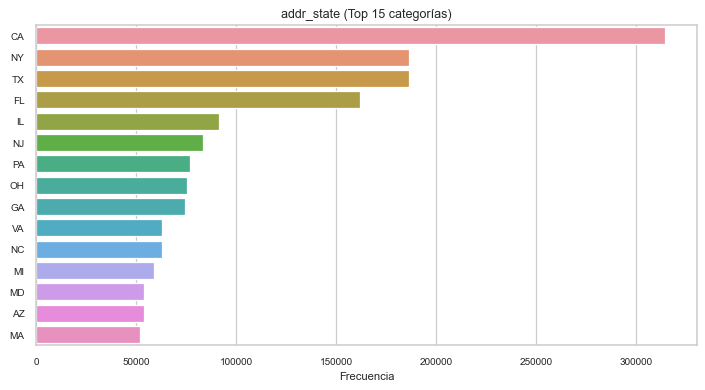

In [10]:
top_states = df["addr_state"].value_counts().head(15).index

plt.figure(figsize=(8, 4.5), dpi=90)
sns.countplot(
    data=df[df["addr_state"].isin(top_states)],
    y="addr_state",
    order=top_states
)
plt.title("addr_state (Top 15 categorías)", fontsize=10)
plt.xlabel("Frecuencia", fontsize=9)
plt.ylabel("")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## **Análisis de la variable objetivo**

Finalmente, se analiza la distribución de la variable objetivo `default`, construida a partir de la columna `loan_status`.

El objetivo de esta subsección es evaluar la proporción de clases en el dataset y determinar si existe desbalance entre los casos de incumplimiento y no incumplimiento, ya que este aspecto puede influir de manera importante en el desempeño de los modelos de clasificación.

In [11]:
default_counts = df["default"].value_counts().sort_index()
default_pct = (df["default"].value_counts(normalize=True).sort_index() * 100).round(2)

default_df = pd.DataFrame({
    "frecuencia": default_counts,
    "porcentaje": default_pct
})

default_df

,frecuencia,porcentaje
0,1992142,88.12
1,268559,11.88


La distribución de la variable objetivo muestra un claro desbalance de clases.

En particular, el **88.12%** de los registros corresponde a la clase **0** (préstamos que no fueron clasificados como `Charged Off`), mientras que solo el **11.88%** corresponde a la clase **1** (préstamos en default).

Este comportamiento indica que el dataset está desbalanceado hacia la clase mayoritaria, lo cual es habitual en problemas de riesgo crediticio, donde los casos de incumplimiento representan una proporción menor del total de préstamos.

Desde el punto de vista del modelado, este desbalance deberá ser considerado en etapas posteriores, ya que puede afectar el desempeño de los algoritmos de clasificación y sesgar las predicciones hacia la clase mayoritaria. Por esta razón, será importante utilizar partición estratificada y métricas adecuadas.

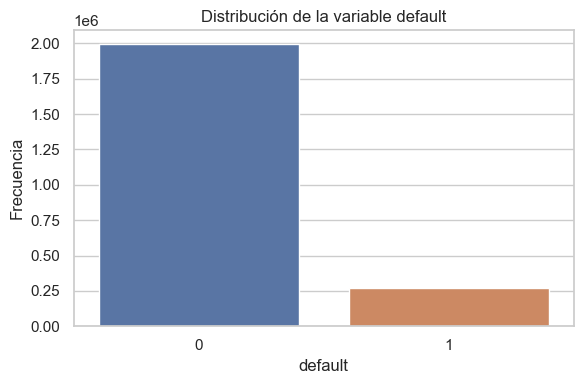

In [12]:
plt.figure(figsize=(6, 4), dpi=100)
sns.countplot(x="default", data=df)
plt.title("Distribución de la variable default")
plt.xlabel("default")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


La visualización confirma el predominio de la clase 0 sobre la clase 1, reforzando la evidencia de desbalance observada en la tabla de frecuencias.

## **Conclusión de la sección**

En esta sección se analizaron las variables categóricas seleccionadas y la variable objetivo `default`. Se evaluó la presencia de valores faltantes, la distribución de las categorías, la existencia de categorías poco frecuentes y el desbalance de clases en la variable objetivo.

Estos resultados servirán como base para el análisis bidimensional y para las decisiones posteriores de preprocesamiento y modelado.